In [30]:
import pandas as pd

#load
df = pd.read_csv("chembl_for_agents.csv")
df = df[['canonical_smiles', 'logP', 'MW', 'HBD', 'HBA']]

print(len(df))
df.head()

12761


,canonical_smiles,logP,MW,HBD,HBA
0,NC(=O)C1(NC(=O)[C@H](Cc2ccccc2)NC(=O)[C@@H](Cc...,2.5882,790.991,8,8
1,O=C1CC[C@H](N2C(=O)c3cccc(NCc4ccc(CN5CC(N6CCOC...,1.3554,535.576,2,8
2,CC(C)OC(=O)C(C(=O)OC(C)C)=C1SC=CS1,3.0524,288.390,0,6
3,C[C@H]1CC(=O)C[C@@H]2CC[C@H]3[C@@H]4CC[C@H](O)...,4.2051,304.474,1,2
4,COc1c2occc2c(OC)c2c(=O)cc(CSC)oc12,3.4194,306.339,0,6


In [31]:
from rdkit import Chem

target_cols = ['logP', 'MW', 'HBD', 'HBA']

smiles_list = df['canonical_smiles'].tolist()
targets = df[target_cols].values

#filter invalid smiles
valid_indices = [i for i, s in enumerate(smiles_list) if Chem.MolFromSmiles(s) is not None]
smiles_list = [smiles_list[i] for i in valid_indices]
targets = targets[valid_indices]

len(targets)

12761

In [32]:
from sklearn.preprocessing import StandardScaler

#scale target
scaler = StandardScaler()
targets_scaled = scaler.fit_transform(targets)

In [33]:
import torch
from torch_geometric.data import Data, Dataset

def mol_to_graph(smiles):
    mol = Chem.MolFromSmiles(smiles)

    #node
    node_features = []
    for atom in mol.GetAtoms():
        feat = [
            atom.GetAtomicNum(),
            atom.GetDegree(),
            atom.GetFormalCharge(),
            int(atom.GetHybridization()),
            int(atom.GetIsAromatic())
        ]
        node_features.append(feat)
    x = torch.tensor(node_features, dtype=torch.float)

    #edge
    edge_index = []
    edge_attr = []
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        edge_index.append([i, j])
        edge_index.append([j, i])
        btype = bond.GetBondType()
        edge_feat = [
            int(btype == Chem.rdchem.BondType.SINGLE),
            int(btype == Chem.rdchem.BondType.DOUBLE),
            int(btype == Chem.rdchem.BondType.TRIPLE),
            int(btype == Chem.rdchem.BondType.AROMATIC),
            int(bond.GetIsConjugated()),
            int(bond.IsInRing())
        ]
        edge_attr.append(edge_feat)
        edge_attr.append(edge_feat)

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_attr, dtype=torch.float)

    return x, edge_index, edge_attr

In [34]:
class MoleculeDataset(Dataset):
    def __init__(self, smiles_list, targets_scaled):
        self.smiles_list = smiles_list
        self.targets = torch.tensor(targets_scaled, dtype=torch.float)
        super().__init__()

    def len(self):
        return len(self.smiles_list)
    
    def get(self, idx):
        smiles = self.smiles_list[idx]
        y = self.targets[idx]
        y = y.unsqueeze(0) if len(y.shape) == 1 else y  # make [1,4] so DataLoader stacks properly
        x, edge_index, edge_attr = mol_to_graph(smiles)
        return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

In [35]:
dataset = MoleculeDataset(smiles_list, targets_scaled)

for i in range(5):
    print(dataset[i])
len(dataset)

Data(x=[57, 5], edge_index=[2, 126], edge_attr=[126, 6], y=[1, 4])
Data(x=[39, 5], edge_index=[2, 88], edge_attr=[88, 6], y=[1, 4])
Data(x=[18, 5], edge_index=[2, 36], edge_attr=[36, 6], y=[1, 4])
Data(x=[22, 5], edge_index=[2, 50], edge_attr=[50, 6], y=[1, 4])
Data(x=[21, 5], edge_index=[2, 46], edge_attr=[46, 6], y=[1, 4])


12761

In [40]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINEConv, global_mean_pool, global_max_pool
from torch_geometric.data import DataLoader

def make_edge_mlp(edge_feat_dim, hidden_dim):
    return nn.Sequential(
        nn.Linear(edge_feat_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, hidden_dim)
    )

def make_node_mlp(in_dim, out_dim):
    return nn.Sequential(
        nn.Linear(in_dim, out_dim),
        nn.ReLU(),
        nn.Linear(out_dim, out_dim)
    )

In [41]:
### MODEL ARCHITECTURE ###

class MoleculeGINE(nn.Module):
    def __init__(self, node_feat_dim, edge_feat_dim, hidden_dim=128, out_dim=4):
        super().__init__()

        self.edge_mlp = make_edge_mlp(edge_feat_dim, hidden_dim)

        #GINE
        self.conv1 = GINEConv(make_node_mlp(node_feat_dim, hidden_dim), edge_dim=hidden_dim)
        self.conv2 = GINEConv(make_node_mlp(hidden_dim, hidden_dim), edge_dim=hidden_dim)
        self.conv3 = GINEConv(make_node_mlp(hidden_dim, hidden_dim), edge_dim=hidden_dim)

        #input projection for residual connection
        self.node_emb = nn.Linear(node_feat_dim, hidden_dim)

        #multi-head
        self.heads = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden_dim * 2, hidden_dim),
                nn.ReLU(),
                nn.Dropout(0.1),
                nn.Linear(hidden_dim, hidden_dim // 2),
                nn.ReLU(),
                nn.Linear(hidden_dim // 2, 1)
            ) for _ in range(out_dim)
        ])

    def forward(self, x, edge_index, edge_attr, batch):
        
        #map edge feature via mlp
        edge_emb = self.edge_mlp(edge_attr)
        
        #3 hops gnn layer with residual connection
        x_res = self.node_emb(x)

        h = F.relu(self.conv1(x, edge_index, edge_emb))
        x = x_res + h

        h = F.relu(self.conv2(x, edge_index, edge_emb))
        x = x + h

        h = F.relu(self.conv3(x, edge_index, edge_emb))
        x = x + h

        #pooling
        x_mean = global_mean_pool(x, batch)
        x_max  = global_max_pool(x, batch)
        x = torch.cat([x_mean, x_max], dim=-1)
        
        #multi-head prediction
        #run pooled vector x on each head
        head_outputs = [head(x) for head in self.heads]

        #concatenate
        out = torch.cat(head_outputs, dim=-1) #[B, 4]
        
        return out


In [42]:
from torch_geometric.data import DataLoader

batch_size = 32
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)


C:\Users\TYC\AppData\Local\Temp\ipykernel_22768\3468504254.py:4: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)


In [ ]:
#training loop
from rdkit import RDLogger

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

model = MoleculeGINE(node_feat_dim=5, edge_feat_dim=6, hidden_dim=128, out_dim=4).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

RDLogger.DisableLog('rdApp.warning')
losses=[]
model.train()
EPOCHS = 200

#200 epochs
for epoch in range(EPOCHS):
    total_loss = 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        pred = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
        loss = criterion(pred, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    print(f"Epoch {epoch+1}: Loss = {total_loss/len(dataset):.4f}")
    losses.append(total_loss/len(dataset))

cuda
Epoch 1: Loss = 0.9000
Epoch 2: Loss = 0.7267
Epoch 3: Loss = 0.6524
Epoch 4: Loss = 0.6324
Epoch 5: Loss = 0.5946
Epoch 6: Loss = 0.5260
Epoch 7: Loss = 0.5029
Epoch 8: Loss = 0.4807
Epoch 9: Loss = 0.4526
Epoch 10: Loss = 0.4291
Epoch 11: Loss = 0.4434
Epoch 12: Loss = 0.4202
Epoch 13: Loss = 0.3804
Epoch 14: Loss = 0.3890
Epoch 15: Loss = 0.3612
Epoch 16: Loss = 0.3630
Epoch 17: Loss = 0.3218
Epoch 18: Loss = 0.3500
Epoch 19: Loss = 0.3733
Epoch 20: Loss = 0.3487
Epoch 21: Loss = 0.3032
Epoch 22: Loss = 0.3068
Epoch 23: Loss = 0.2791
Epoch 24: Loss = 0.2821
Epoch 25: Loss = 0.2785
Epoch 26: Loss = 0.2576
Epoch 27: Loss = 0.2227
Epoch 28: Loss = 0.2546
Epoch 29: Loss = 0.3636
Epoch 30: Loss = 0.2906
Epoch 31: Loss = 0.2156
Epoch 32: Loss = 0.2398
Epoch 33: Loss = 0.2017
Epoch 34: Loss = 0.2047
Epoch 35: Loss = 0.2030
Epoch 36: Loss = 0.2223
Epoch 37: Loss = 0.2171
Epoch 38: Loss = 0.1821
Epoch 39: Loss = 0.1758
Epoch 40: Loss = 0.2264
Epoch 41: Loss = 0.1861
Epoch 42: Loss = 0.1

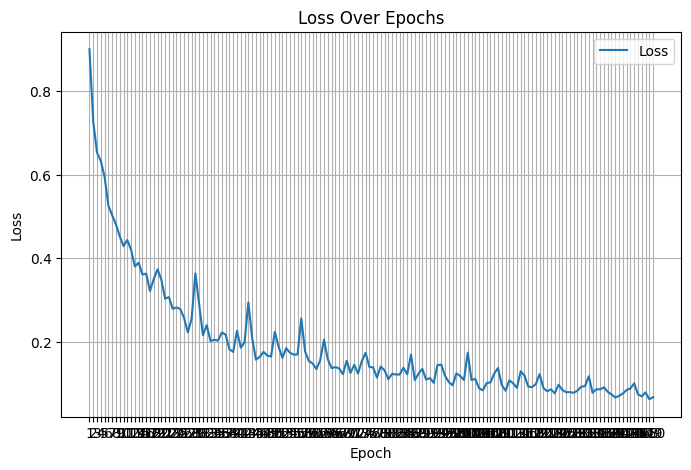

In [45]:
import matplotlib.pyplot as plt

#loss graph
epochs_g = range(1, EPOCHS+1)  # Start from 1

plt.figure(figsize=(8,5))
plt.plot(epochs_g, losses, label="Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Over Epochs")
plt.xticks(epochs_g)  #show each epoch number
plt.legend()
plt.grid(True)
plt.show()

In [46]:
#test
def predict_properties(smiles, model, scaler, device="cuda"):
    model.eval()

    x, edge_index, edge_attr = mol_to_graph(smiles)

    data = Data(
        x=x.to(device),
        edge_index=edge_index.to(device),
        edge_attr=edge_attr.to(device),
        batch=torch.zeros(x.size(0), dtype=torch.long).to(device)
    )

    with torch.no_grad():
        pred_scaled = model(data.x, data.edge_index, data.edge_attr, data.batch)

    pred = scaler.inverse_transform(pred_scaled.cpu().numpy())[0]

    return {
        "logP": float(pred[0]),
        "MW": float(pred[1]),
        "HBD": round(float(pred[2])),
        "HBA": round(float(pred[3]))
    }

In [48]:
test_smiles = "O=C1N=C2SCCN2C(=O)C1Cc1ccc(Cl)cc1"
predict_properties(test_smiles, model, scaler)

{'logP': 1.888139009475708, 'MW': 296.59954833984375, 'HBD': 1, 'HBA': 4}

In [49]:
import joblib

torch.save(model, "prop_gnn.pt")
joblib.dump(scaler, "scaler_for_gnn.pkl")

['scaler_for_gnn.pkl']